### Lecture et parsing du fichier cowrie de logs SSH → DataFrame

In [10]:
import json
import pandas as pd

path = "../ml/data/cowrie.json"

rows = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line=line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_ssh = pd.DataFrame(rows)
#df_ssh.head()
df_ssh

,eventid,src_ip,src_port,dst_ip,dst_port,session,protocol,message,sensor,uuid,...,langCS,username,password,width,height,name,value,arch,input,duration
0,cowrie.session.connect,172.20.0.1,38892.0,172.20.0.5,2222.0,4f2f26b2ccf4,ssh,New connection: 172.20.0.1:38892 (172.20.0.5:2...,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cowrie.client.version,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,Remote SSH version: SSH-2.0-OpenSSH_8.9p1 Ubun...,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cowrie.client.kex,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,SSH client hassh fingerprint: e1d88fdd485f9c71...,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cowrie.login.success,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,login attempt [root/letmein] succeeded,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,root,letmein,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cowrie.client.size,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,Terminal Size: 120 30,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,120.0,30.0,NaN,NaN,NaN,NaN,NaN
5,cowrie.client.var,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,request_env: LANG=C.UTF-8,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,LANG,C.UTF-8,NaN,NaN,NaN
6,cowrie.session.params,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,[],d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linux-x64-lsb,NaN,NaN
7,cowrie.command.input,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,CMD: ls,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ls,NaN
8,cowrie.command.input,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,CMD: ls -l,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ls -l,NaN
9,cowrie.command.input,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,CMD: ls -al,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ls -al,NaN


### Graphiques SSH (eventid, commandes)

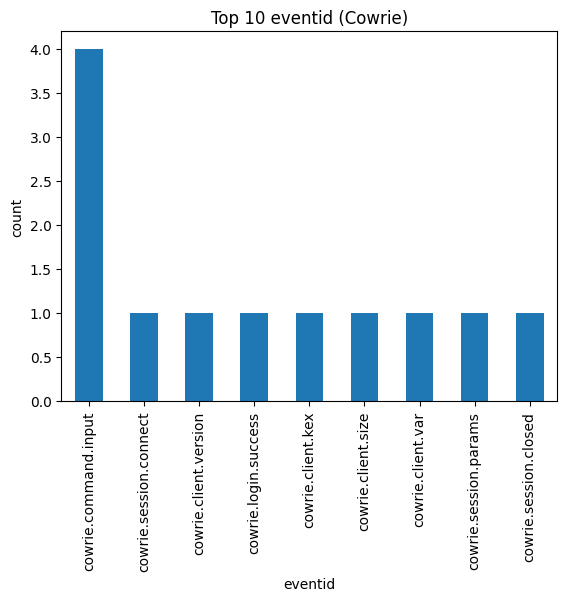

In [12]:
import matplotlib.pyplot as plt

df_ssh["eventid"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 eventid (Cowrie)")
plt.xlabel("eventid")
plt.ylabel("count")
plt.show()

### Commandes (cowrie.command.input) 

In [13]:
cmds = df_ssh[df_ssh["eventid"] == "cowrie.command.input"]["input"].dropna()
cmds.head(20)

7         ls
8      ls -l
9     ls -al
10        id
Name: input, dtype: object

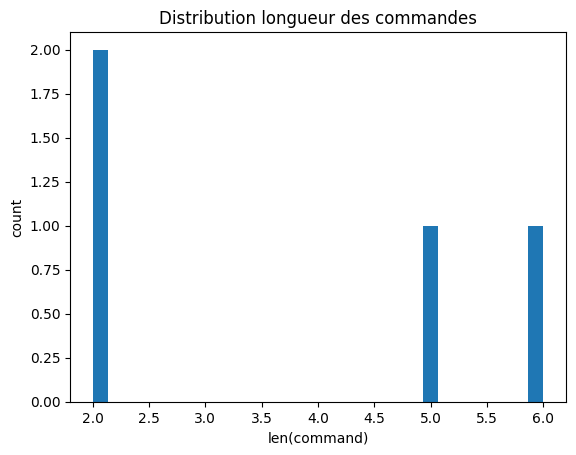

In [16]:
cmd_len = cmds.astype(str).str.len()

cmd_len.plot(kind="hist", bins=30)
plt.title("Distribution longueur des commandes")
plt.xlabel("len(command)")
plt.ylabel("count")
plt.show()

### Histogramme longueur commandes 

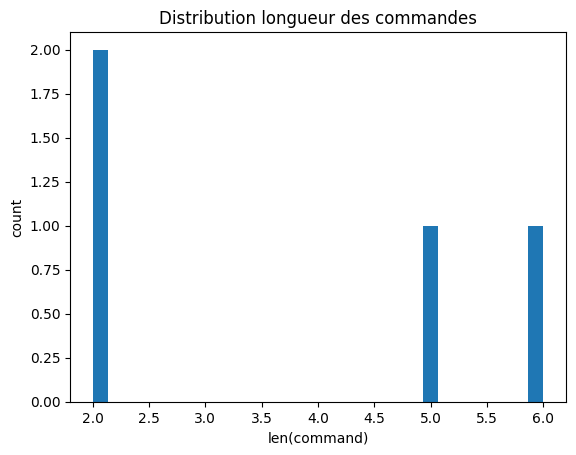

In [17]:
cmd_len = cmds.astype(str).str.len()

cmd_len.plot(kind="hist", bins=30)
plt.title("Distribution longueur des commandes")
plt.xlabel("len(command)")
plt.ylabel("count")
plt.show()

### Score du Modèle

In [19]:
import sys
sys.path.append("../ml")

import joblib
import numpy as np
from feature_extraction import featurize_ssh_cowrie

In [21]:
model_ssh = joblib.load("../ml/model_ssh.joblib")

X_ssh = np.array([featurize_ssh_cowrie(ev, fails_60s=0) for ev in rows], dtype=float)

scores_ssh = model_ssh.score_samples(X_ssh)
preds_ssh = model_ssh.predict(X_ssh)

df_ssh["ml_score"] = scores_ssh
df_ssh["ml_pred"] = preds_ssh

df_ssh.head()

,eventid,src_ip,src_port,dst_ip,dst_port,session,protocol,message,sensor,uuid,...,password,width,height,name,value,arch,input,duration,ml_score,ml_pred
0,cowrie.session.connect,172.20.0.1,38892.0,172.20.0.5,2222.0,4f2f26b2ccf4,ssh,New connection: 172.20.0.1:38892 (172.20.0.5:2...,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.394557,1
1,cowrie.client.version,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,Remote SSH version: SSH-2.0-OpenSSH_8.9p1 Ubun...,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.394557,1
2,cowrie.client.kex,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,SSH client hassh fingerprint: e1d88fdd485f9c71...,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.394557,1
3,cowrie.login.success,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,login attempt [root/letmein] succeeded,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,letmein,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.644891,1
4,cowrie.client.size,172.20.0.1,NaN,NaN,NaN,4f2f26b2ccf4,ssh,Terminal Size: 120 30,d2e02af6e985,440efca0-fc58-11f0-849c-7aba4c68aaec,...,NaN,120.0,30.0,NaN,NaN,NaN,NaN,NaN,-0.394557,1


### Distribution des scores SSH

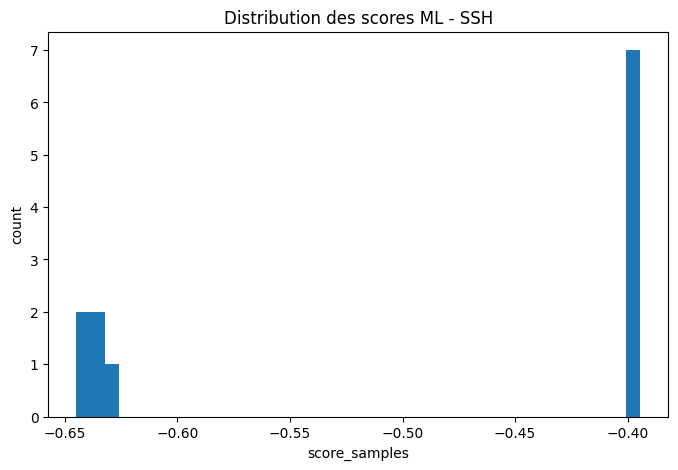

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df_ssh["ml_score"], bins=40)
plt.title("Distribution des scores ML - SSH")
plt.xlabel("score_samples")
plt.ylabel("count")
plt.show()

### Top Anomalie SSH

In [24]:
anomalies_ssh = df_ssh[df_ssh["ml_pred"] == -1].copy()
anomalies_ssh = anomalies_ssh.sort_values("ml_score")

anomalies_ssh[["eventid", "username", "input", "ml_score"]].head(10)

,eventid,username,input,ml_score


### Affichage le taux d’anomalie SSH

In [25]:
(len(df_ssh[df_ssh["ml_pred"] == -1]) / len(df_ssh)) * 100

0.0

In [27]:
print("SSH anomalies:", round((df_ssh["ml_pred"] == -1).mean() * 100, 2), "%")


SSH anomalies: 0.0 %


### Graphiques SSH (eventid, commandes)


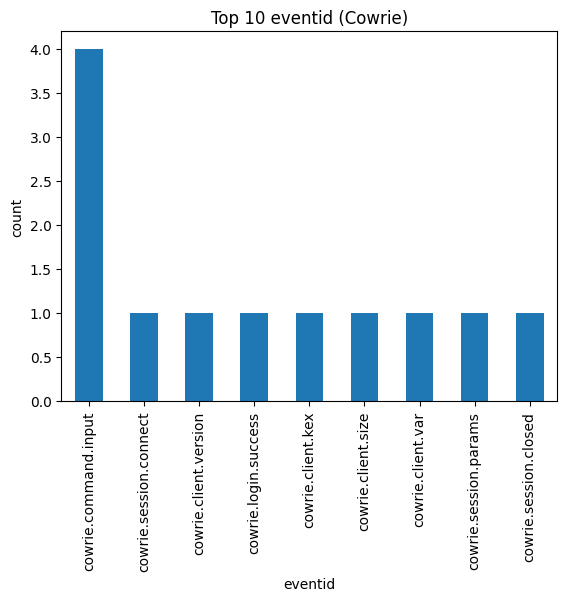

In [2]:
import matplotlib.pyplot as plt

df_ssh["eventid"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 eventid (Cowrie)")
plt.xlabel("eventid")
plt.ylabel("count")
plt.show()

In [3]:
cmds = df_ssh[df_ssh["eventid"] == "cowrie.command.input"]["input"].dropna()
cmds.head(20)

7         ls
8      ls -l
9     ls -al
10        id
Name: input, dtype: object

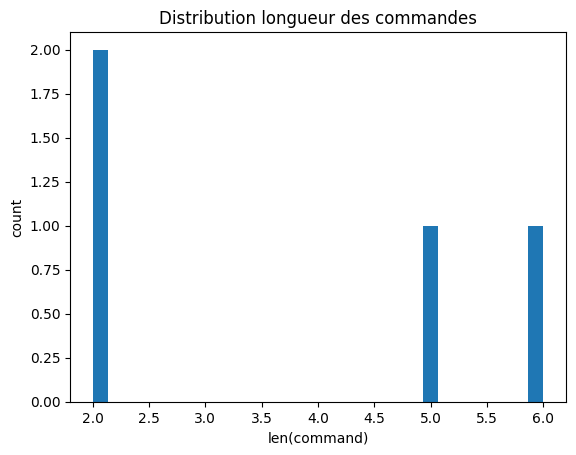

In [4]:
cmd_len = cmds.astype(str).str.len()

cmd_len.plot(kind="hist", bins=30)
plt.title("Distribution longueur des commandes")
plt.xlabel("len(command)")
plt.ylabel("count")
plt.show()